##  Jour 4 — La Descente de Gradient

###  Concept Théorique

La **descente de gradient** est l'algorithme qui permet au réseau d'**apprendre**. C'est le mécanisme qui ajuste les poids pour minimiser la loss.

Le principe : on calcule la direction dans laquelle la loss diminue le plus vite (le gradient), puis on fait un petit pas dans cette direction.

###  Intuition

Imaginez que vous êtes **les yeux bandés au sommet d'une montagne** et vous voulez descendre dans la vallée :
1. Vous tâtez le sol autour de vous pour sentir la **pente** (= calcul du gradient)
2. Vous faites un **pas** dans la direction la plus descendante (= mise à jour des poids)
3. Vous **répétez** jusqu'à atteindre le point le plus bas (= minimum de la loss)

La taille du pas = le **learning rate** ($\alpha$) :
- Trop grand → vous sautez par-dessus la vallée
- Trop petit → vous mettez une éternité à descendre
- Juste bien → vous convergez efficacement

###  Formules Essentielles

**Règle de mise à jour :**

$$w \leftarrow w - \alpha \cdot \frac{\partial \mathcal{L}}{\partial w}$$

Où :
- $w$ : le poids à mettre à jour
- $\alpha$ : le learning rate (typiquement 0.01, 0.001)
- $\frac{\partial \mathcal{L}}{\partial w}$ : le gradient de la loss par rapport à $w$

###  Implémentation From Scratch


=== Descente de Gradient sur f(x) = (x-3)² + 1 ===

  Itération   1 : x =  -3.4000, f(x) =  41.9600, gradient = -16.0000
  Itération   2 : x =  -2.1200, f(x) =  27.2144, gradient = -12.8000
  Itération   3 : x =  -1.0960, f(x) =  17.7772, gradient = -10.2400
  Itération   4 : x =  -0.2768, f(x) =  11.7374, gradient =  -8.1920
  Itération   5 : x =   0.3786, f(x) =   7.8719, gradient =  -6.5536
  Itération   6 : x =   0.9028, f(x) =   5.3980, gradient =  -5.2429
  Itération   7 : x =   1.3223, f(x) =   3.8147, gradient =  -4.1943
  Itération   8 : x =   1.6578, f(x) =   2.8014, gradient =  -3.3554
  Itération   9 : x =   1.9263, f(x) =   2.1529, gradient =  -2.6844
  Itération  10 : x =   2.1410, f(x) =   1.7379, gradient =  -2.1475
  Itération  11 : x =   2.3128, f(x) =   1.4722, gradient =  -1.7180
  Itération  21 : x =   2.9262, f(x) =   1.0054, gradient =  -0.1845
  Itération  31 : x =   2.9921, f(x) =   1.0001, gradient =  -0.0198
  Itération  41 : x =   2.9991, f(x) =   1.0000, gr

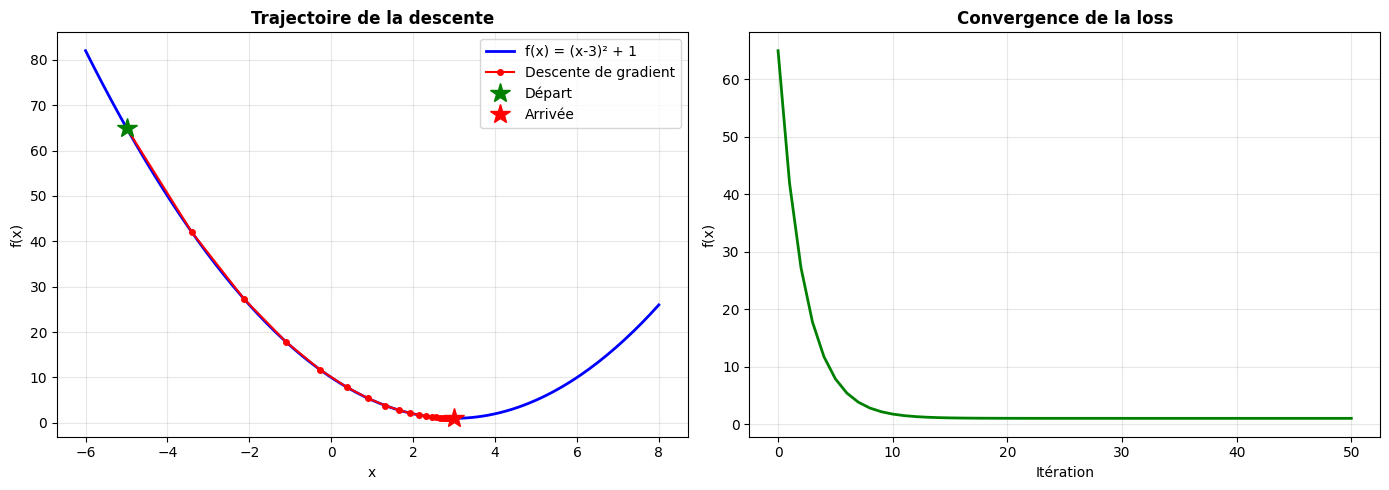


=== Effet du Learning Rate ===



C:\Users\riahi\AppData\Local\Temp\ipykernel_23024\2915058782.py:103: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\riahi\AppData\Local\Temp\ipykernel_23024\2915058782.py:103: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\riahi\AppData\Local\Temp\ipykernel_23024\2915058782.py:104: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("learning_rate_effect.png", dpi=150)
C:\Users\riahi\AppData\Local\Temp\ipykernel_23024\2915058782.py:104: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("learning_rate_effect.png", dpi=150)
c:\Users\riahi\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\riahi\AppData\Local\Pr

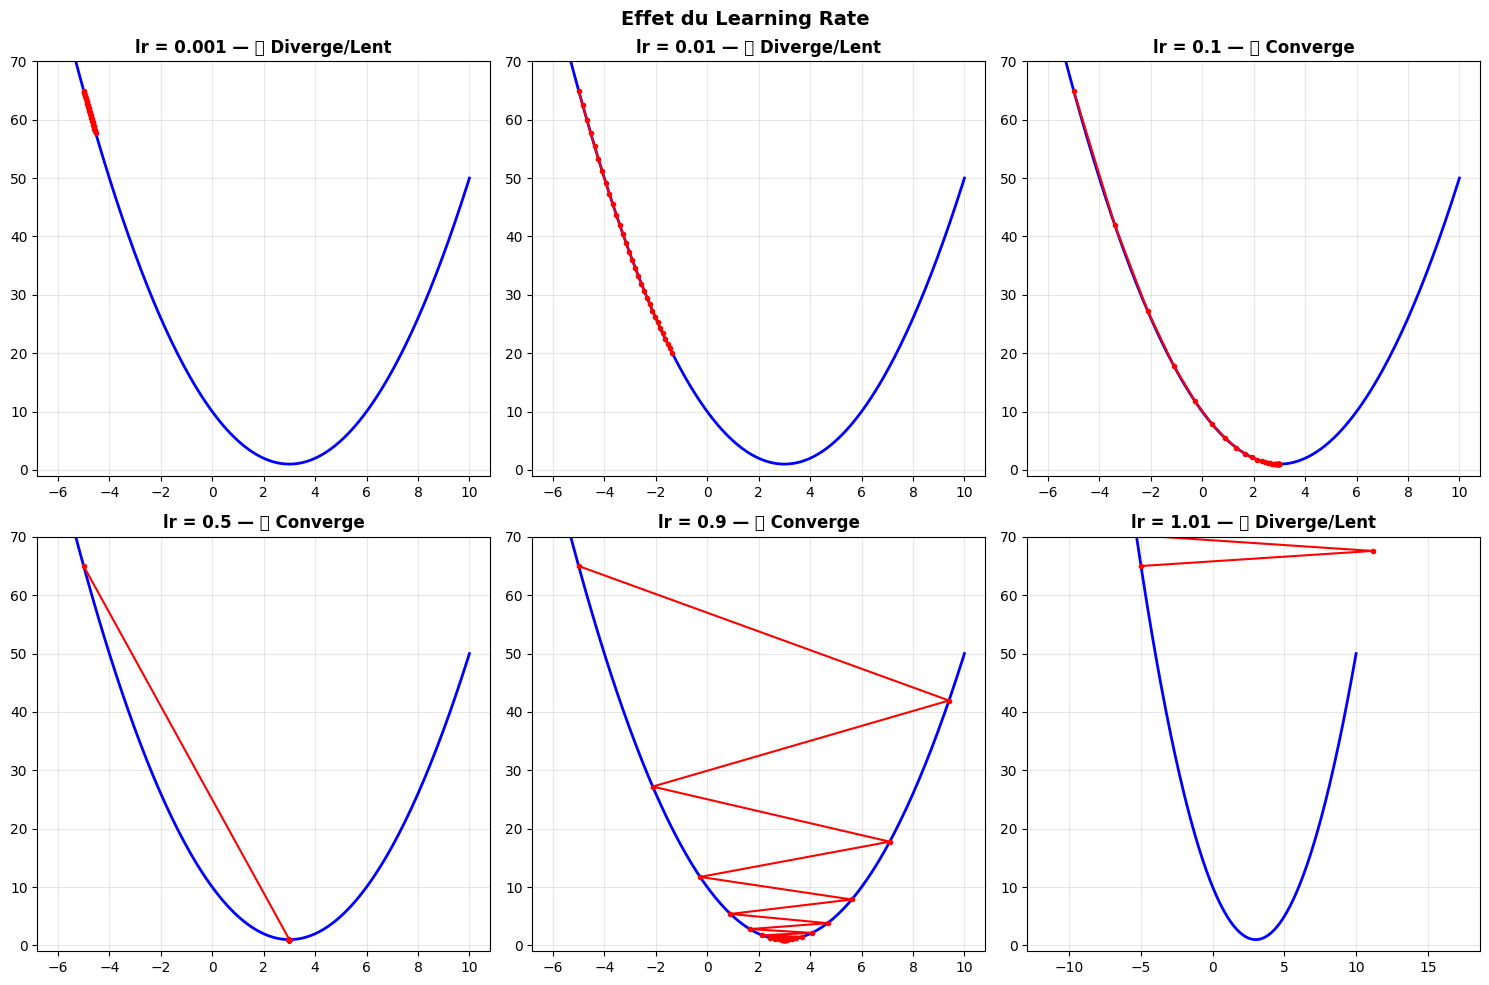

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# JOUR 4 : La Descente de Gradient
# ============================================================

# --- Exemple 1 : Minimiser une fonction simple ---
# Trouvons le minimum de f(x) = (x - 3)² + 1
# Le minimum est évidemment x = 3, f(3) = 1
# Mais faisons-le trouver par la descente de gradient !

def f(x):
    """La fonction à minimiser."""
    return (x - 3) ** 2 + 1

def df(x):
    """La dérivée de f (le gradient)."""
    return 2 * (x - 3)  # df/dx = 2(x - 3)

# Paramètres
x = -5.0            # point de départ (loin du minimum)
learning_rate = 0.1  # taille du pas
n_iterations = 50    # nombre d'itérations

# Historique pour la visualisation
history_x = [x]
history_f = [f(x)]

print("=== Descente de Gradient sur f(x) = (x-3)² + 1 ===\n")

for i in range(n_iterations):
    gradient = df(x)              # 1. Calculer le gradient
    x = x - learning_rate * gradient  # 2. Mettre à jour x
    
    history_x.append(x)
    history_f.append(f(x))
    
    if i < 10 or i % 10 == 0:  # afficher les 10 premières + tous les 10
        print(f"  Itération {i+1:>3} : x = {x:>8.4f}, f(x) = {f(x):>8.4f}, gradient = {gradient:>8.4f}")

print(f"\n  Résultat final : x = {x:.6f} (attendu : 3.0)")
print(f"  f(x) finale    : {f(x):.6f} (attendu : 1.0)")

# --- Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 : Trajectoire sur la fonction
x_plot = np.linspace(-6, 8, 200)
axes[0].plot(x_plot, f(x_plot), 'b-', linewidth=2, label="f(x) = (x-3)² + 1")
axes[0].plot(history_x, history_f, 'ro-', markersize=4, label="Descente de gradient")
axes[0].plot(history_x[0], history_f[0], 'g*', markersize=15, label="Départ")
axes[0].plot(history_x[-1], history_f[-1], 'r*', markersize=15, label="Arrivée")
axes[0].set_title("Trajectoire de la descente", fontweight='bold')
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 : Loss au fil des itérations
axes[1].plot(history_f, 'g-', linewidth=2)
axes[1].set_title("Convergence de la loss", fontweight='bold')
axes[1].set_xlabel("Itération")
axes[1].set_ylabel("f(x)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("gradient_descent.png", dpi=150)
plt.show()

# --- Exemple 2 : Effet du learning rate ---
print("\n=== Effet du Learning Rate ===\n")

learning_rates = [0.001, 0.01, 0.1, 0.5, 0.9, 1.01]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, lr in enumerate(learning_rates):
    x = -5.0
    history = [x]
    
    for _ in range(30):
        x = x - lr * df(x)
        history.append(x)
        if abs(x) > 1000:  # divergence !
            break
    
    # Visualisation
    x_plot = np.linspace(-6, 10, 200)
    axes[idx].plot(x_plot, f(x_plot), 'b-', linewidth=2)
    history_f_plot = [f(h) for h in history if abs(h) < 100]
    history_clipped = [h for h in history if abs(h) < 100]
    if history_clipped:
        axes[idx].plot(history_clipped, history_f_plot, 'ro-', markersize=3)
    
    converged = abs(history[-1] - 3) < 0.1 if abs(history[-1]) < 1000 else False
    status = "✅ Converge" if converged else "❌ Diverge/Lent"
    axes[idx].set_title(f"lr = {lr} — {status}", fontweight='bold')
    axes[idx].set_ylim(-1, 70)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("Effet du Learning Rate", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("learning_rate_effect.png", dpi=150)
plt.show()


###  Règles d'or du Learning Rate

| Learning Rate | Effet |
|---|---|
| Trop petit (0.0001) | Convergence très lente, risque de rester coincé |
| Bon (0.001 - 0.01) | Convergence stable et régulière |
| Trop grand (> 1.0) | Oscillation ou divergence ! |